In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt


In [3]:
# 1. 读取数据（假设你的原始文件已经生成了包含所有特征的 CSV 文件）
df = pd.read_csv("数据模型.csv")

In [4]:
# 将 FireFrequency 转成二分类：>0 就视为发生火灾 fire_occur
df["fire_occur"] = (df["FireFrequency"] > 0).astype(int)

In [5]:
# ========== 2. 在同一年同一月内，计算“空间邻域特征” ==========
#   例如：FireFrequency_neighbor_mean = 邻近 8 个格子的 FireFrequency 平均值

def compute_spatial_neighbor_mean(df_one_month, target_col="FireFrequency"):
    """
    在 df_one_month 这个 DataFrame里，为每个 (row_index, col_index) 计算其邻域的 target_col 均值
    邻域指上下左右 + 四个对角共8格(不含自己)
    """
    df_one_month = df_one_month.copy()

    # 为了合并邻居值，我们要把 df_one_month 复制并 shift
    neighbor_cols = []
    for dx in [-1, 0, 1]:
        for dy in [-1, 0, 1]:
            if dx == 0 and dy == 0:
                continue
            temp = df_one_month[["row_index", "col_index", target_col]].copy()
            temp["row_index"] += dx
            temp["col_index"] += dy
            new_col = f"{target_col}_n_{dx}_{dy}"
            temp.rename(columns={target_col: new_col}, inplace=True)

            df_one_month = df_one_month.merge(
                temp, on=["row_index", "col_index"], how="left"
            )
            neighbor_cols.append(new_col)

    # 计算邻域平均
    df_one_month[f"{target_col}_neighbor_mean"] = df_one_month[neighbor_cols].mean(axis=1)

    # 你也可以把邻域列都删掉，只保留最终均值
    # df_one_month.drop(columns=neighbor_cols, inplace=True)

    return df_one_month

In [6]:
def compute_spatial_features(df, target_col="FireFrequency"):
    """
    对全表 df 按 (year, month) 分组，在每个分组内计算邻域特征，再合并
    """
    df_result_list = []
    for (y, m), group in df.groupby(["year", "month"]):
        group_processed = compute_spatial_neighbor_mean(group, target_col=target_col)
        df_result_list.append(group_processed)
    # 合并回一个大表
    df_with_neighbor = pd.concat(df_result_list, ignore_index=True)
    return df_with_neighbor

In [7]:
# 调用函数，生成带有 FireFrequency_neighbor_mean 的大表
df = compute_spatial_features(df, target_col="FireFrequency")

# ========== 3. 构建训练 / 测试集 ==========
#   以 2018~2023 年为训练集，2024 年为测试集

train_df = df[df["year"].between(2018, 2023)]
test_df = df[df["year"] == 2024]

# 选取特征列（示例）
feature_cols = [
    "Population", "Rain", "WindDirection", "WindSpeed", "Temperature",
    "ForestCoverRate", "ConservationAndNaturalEnvironments.y",
    "ProductionFromRelativelyNaturalEnvironments.y",
    "ProductionFromDrylandAgricultureAndPlantations.y",
    "ProductionFromIrrigatedAgricultureAndPlantations.y",
    "IntensiveUses.y", "Water.y",
    "WindDirection_rad", "Wind_U", "Wind_V",
    "month_sin", "month_cos",
    # 新增的空间邻域均值
    "FireFrequency_neighbor_mean"
]

X_train = train_df[feature_cols].fillna(0)
y_train = train_df["fire_occur"]

X_test = test_df[feature_cols].fillna(0)
y_test = test_df["fire_occur"]

In [13]:
# ========== 4. 训练多个模型并比较 ==========
models = {
    "Logistic": LogisticRegression(max_iter=1000),
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": xgb.XGBClassifier(
        n_estimators=100, learning_rate=0.1, random_state=42,
        use_label_encoder=False, eval_metric="logloss"
    ),
    "LightGBM": lgb.LGBMClassifier(n_estimators=100, learning_rate=0.1, random_state=42),
}

predictions = {}
probas = {}
for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    # 保存预测结果
    predictions[model_name] = y_pred
    probas[model_name] = y_proba

    # 输出评估
    print(f"=== {model_name} ===")
    print(classification_report(y_test, y_pred))
    print("AUC:", roc_auc_score(y_test, y_proba))
    
    # 查看模型的系数或特征重要性
    if hasattr(model, "coef_"):
        print("Coefficients:", model.coef_)
        print("Intercept:", model.intercept_)
    elif hasattr(model, "feature_importances_"):
        print("Feature Importances:", model.feature_importances_)
    print()


C:\Users\21061\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


=== Logistic ===
              precision    recall  f1-score   support

           0       0.85      0.96      0.90     27993
           1       0.74      0.40      0.52      7743

    accuracy                           0.84     35736
   macro avg       0.80      0.68      0.71     35736
weighted avg       0.83      0.84      0.82     35736

AUC: 0.8646071178132904
Coefficients: [[ 3.60852370e-03 -2.41729473e-02 -4.73692227e-04 -9.29066100e-02
   6.35672963e-01  1.65147390e+00 -1.02813637e+00 -6.81849047e-01
   2.21931287e-01  6.22154155e-01 -2.01770650e-01 -5.70960879e-01
  -8.26829400e-06 -2.51012834e-03 -5.92736098e-02 -2.01458370e-03
  -1.09040897e-01  8.64852208e-01]]
Intercept: [-1.6538221]

=== RandomForest ===
              precision    recall  f1-score   support

           0       0.89      0.94      0.91     27993
           1       0.73      0.58      0.65      7743

    accuracy                           0.86     35736
   macro avg       0.81      0.76      0.78     35736


C:\Users\21061\AppData\Roaming\Python\Python312\site-packages\xgboost\core.py:158: UserWarning: [19:58:31] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0ed59c031377d09b8-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


=== XGBoost ===
              precision    recall  f1-score   support

           0       0.90      0.93      0.91     27993
           1       0.72      0.61      0.66      7743

    accuracy                           0.86     35736
   macro avg       0.81      0.77      0.79     35736
weighted avg       0.86      0.86      0.86     35736

AUC: 0.9053935178043694
Feature Importances: [0.0420279  0.01120193 0.00593567 0.01121402 0.01431202 0.01586726
 0.01628028 0.02262025 0.03416036 0.00632549 0.01142394 0.01834851
 0.         0.00624968 0.0084047  0.01571216 0.01918882 0.74072707]

[LightGBM] [Info] Number of positive: 49086, number of negative: 165330
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002697 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2581
[LightGBM] [Info] Number of data points in the train set: 214416, number of u

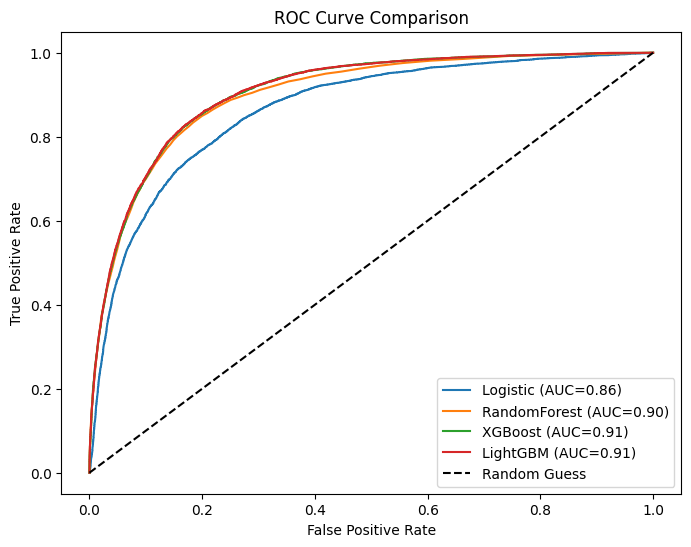

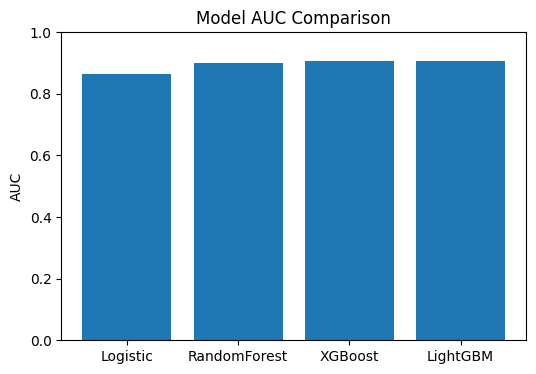

In [14]:
# ========== 5. 可视化 ROC 曲线 + AUC 柱状图 ==========
def get_roc_data(y_true, proba):
    fpr, tpr, _ = roc_curve(y_true, proba)
    auc_val = roc_auc_score(y_true, proba)
    return fpr, tpr, auc_val

plt.figure(figsize=(8,6))
for model_name in models:
    fpr, tpr, auc_val = get_roc_data(y_test, probas[model_name])
    plt.plot(fpr, tpr, label=f"{model_name} (AUC={auc_val:.2f})")
plt.plot([0,1],[0,1],'k--',label='Random Guess')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

auc_scores = [roc_auc_score(y_test, probas[m]) for m in models]
plt.figure(figsize=(6,4))
plt.bar(models.keys(), auc_scores)
plt.ylim(0,1)
plt.ylabel("AUC")
plt.title("Model AUC Comparison")
plt.show()

In [16]:
# ========== 6. 合并预测结果并保存 ==========
test_df["fire_occur_true"] = y_test.values
for m in models:
    test_df[f"{m}_prob"] = probas[m]

test_df[["year","month","id","fire_occur_true"] + [f"{m}_prob" for m in models]].to_excel("AllMonth_WithNeighbor_Prediction.xlsx", index=False)
print("预测结果已保存到 AllMonth_WithNeighbor_Prediction.xlsx")

C:\Users\21061\AppData\Local\Temp\ipykernel_1856\3637100079.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df["fire_occur_true"] = y_test.values
C:\Users\21061\AppData\Local\Temp\ipykernel_1856\3637100079.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df[f"{m}_prob"] = probas[m]


预测结果已保存到 AllMonth_WithNeighbor_Prediction.xlsx
